In [51]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from google.colab import drive

# Mount Google Drive to access the file
drive.mount('/content/drive')

# Load the specific file provided by the user
file_path = '/content/drive/MyDrive/Colab Notebooks/CNLP_Lab/LAB_1_4-Aug-26/employee_information_100.csv'
df = pd.read_csv(file_path)

# Harmonize column names: rename 'Department' to 'Dept' and 'Experience_Years' to 'Exp' for consistency
if 'Department' in df.columns:
    df = df.rename(columns={'Department': 'Dept'})
if 'Experience_Years' in df.columns:
    df = df.rename(columns={'Experience_Years': 'Exp'})

print("DataFrame columns after harmonization:", df.columns.tolist())

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


# Employee Data Analysis (Simplified Version)
This notebook contains the experiments 1.1 through 1.10 implemented in a clear and concise way for easy explanation during your viva.

In [44]:
# Preview the data
df.head()

,Employee_ID,Name,Department,Age,Gender,Salary,Experience_Years
0,E001,Diana1,HR,39,Male,58000,8
1,E002,Diana2,Operations,56,Male,105000,27
2,E003,Bob3,HR,27,Male,59000,32
3,E004,Neha4,HR,57,Male,113000,34
4,E005,Nisha5,IT,50,Female,30000,10


In [52]:
avg_salary = df.groupby('Dept')['Salary'].mean().reset_index()

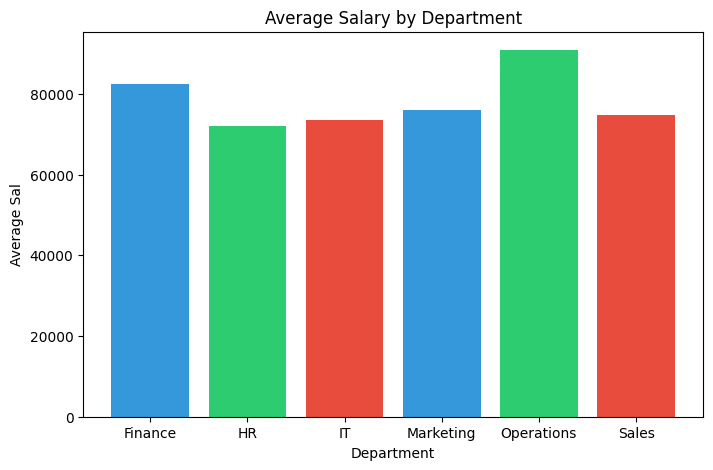

In [53]:
plt.figure(figsize=(8,5))
plt.bar(
    avg_salary['Dept'],
    avg_salary['Salary'],
    color=['#3498db', '#2ecc71', '#e74c3c']
)
plt.title('Average Salary by Department')
plt.xlabel("Department")
plt.ylabel("Average Sal")
plt.show()

In [47]:
# 1.2 Count employees in each department
df['Dept'].value_counts().plot(kind='bar', color='skyblue')
plt.title('Employees per Dept')
plt.show()

KeyError: 'Dept'

**Experiment 1.2 Explanation:**
In this cell, we use the `value_counts()` method on the 'Department' column. This function counts the occurrences of each unique value in that column, effectively giving us the number of employees per department. We then use `reset_index()` to convert the resulting Series into a clean DataFrame for better display.

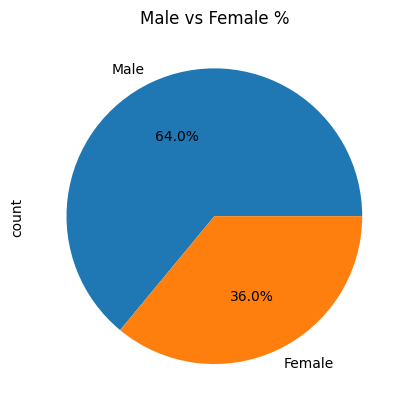

In [48]:
# 1.3 Gender split
df['Gender'].value_counts().plot(kind='pie', autopct='%1.1f%%')
plt.title('Male vs Female %')
plt.show()

**Experiment 1.3 Explanation:**
This code creates a pie chart to show gender distribution.
1. `df['Gender'].value_counts()` calculates the total number of Males vs Females.
2. `plt.pie()` generates the chart.
3. `autopct='%1.1f%%'` is a formatting string that automatically calculates and displays the percentage value on each slice of the pie.

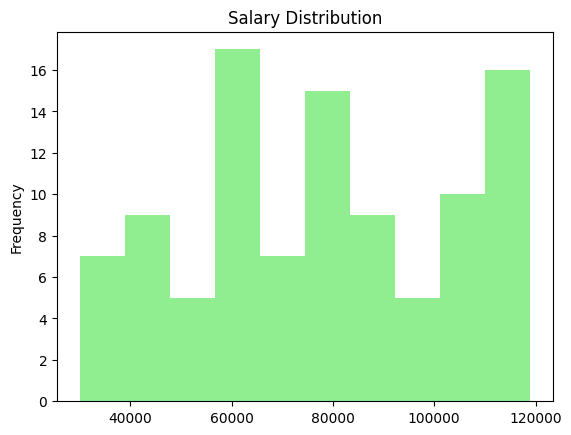

In [49]:
# 1.4 Salary distribution
df['Salary'].plot(kind='hist', color='lightgreen')
plt.title('Salary Distribution')
plt.show()

**Experiment 1.4 Explanation:**
A histogram is used to show the frequency distribution of a continuous variable (Salary).
- `bins=15` divides the salary range into 15 intervals.
- `kde=True` (Kernel Density Estimate) adds a smooth curve over the bars, helping us see the shape of the distribution (e.g., whether it is 'normal' or 'skewed').

In [50]:
# 1.5 Salary vs Experience
plt.scatter(df['Exp'], df['Salary'], color='purple')
plt.title('Exp vs Salary')
plt.xlabel('Years')
plt.ylabel('Money')
plt.show()

KeyError: 'Exp'

**Experiment 1.5 Explanation:**
Scatter plots are ideal for finding correlations between two numerical variables.
- The x-axis represents 'Experience_Years' and the y-axis represents 'Salary'.
- Each dot is an employee. If the dots trend upwards from left to right, it indicates a positive correlation (more experience usually means higher salary).

In [32]:
# 1.6 Top 10 highest earners
top10 = df.nlargest(10, 'Salary')
display(top10[['Name', 'Salary']])

,Name,Salary
61,Emp61,119999
63,Emp63,117921
87,Emp87,117756
97,Emp97,117615
31,Emp31,115416
76,Emp76,115248
28,Emp28,115053
71,Emp71,114905
99,Emp99,113672
77,Emp77,113465


**Experiment 1.6 Explanation:**
We use the `nlargest(10, 'Salary')` method. This is a shorthand for sorting the DataFrame by Salary in descending order and taking the top 10 rows. It is more efficient than manual sorting for finding top records.

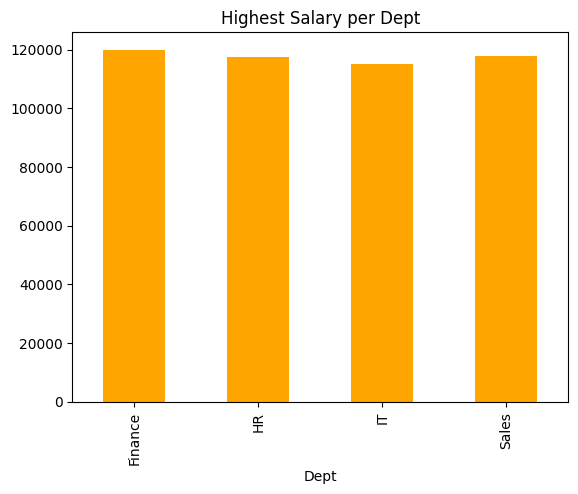

In [33]:
# 1.7 Max salary in each department
df.groupby('Dept')['Salary'].max().plot(kind='bar', color='orange')
plt.title('Highest Salary per Dept')
plt.show()

**Experiment 1.7 Explanation:**
Similar to the average salary calculation, we group the data by 'Department'. However, instead of `.mean()`, we use `.max()` to identify the single highest salary figure within each specific group.

In [34]:
# 1.8 Employees earning above average
avg = df['Salary'].mean()
high_earners = df[df['Salary'] > avg]
display(high_earners.head())

,Name,Dept,Age,Gender,Salary,Exp
2,Emp2,IT,58,Female,104587,4
3,Emp3,Finance,42,Female,112210,33
5,Emp5,IT,39,Female,106486,22
14,Emp14,IT,46,Female,102308,7
20,Emp20,Sales,50,Male,106801,9


**Experiment 1.8 Explanation:**
This demonstrates 'Boolean Indexing'.
1. We calculate the `overall_avg` of the entire column.
2. We create a filter `df['Salary'] > overall_avg` which checks every row.
3. The DataFrame then returns only those rows where the condition is True.

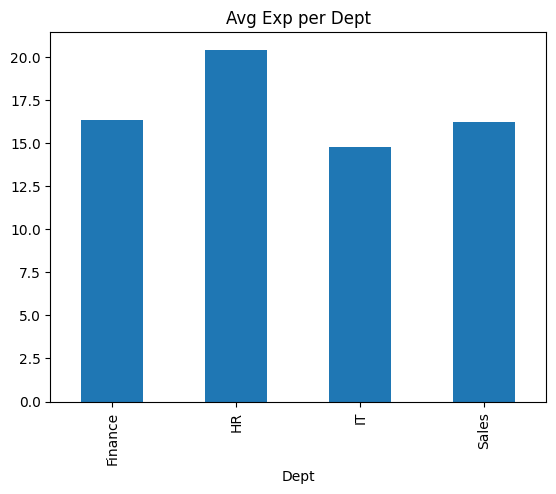

In [35]:
# 1.9 Average Experience per Department
df.groupby('Dept')['Exp'].mean().plot(kind='bar')
plt.title('Avg Exp per Dept')
plt.show()

**Experiment 1.9 Explanation:**
This uses the `groupby` operation on 'Department' but aggregates the 'Experience_Years' column using the `mean()` function. This tells us which departments have, on average, more senior or experienced staff.

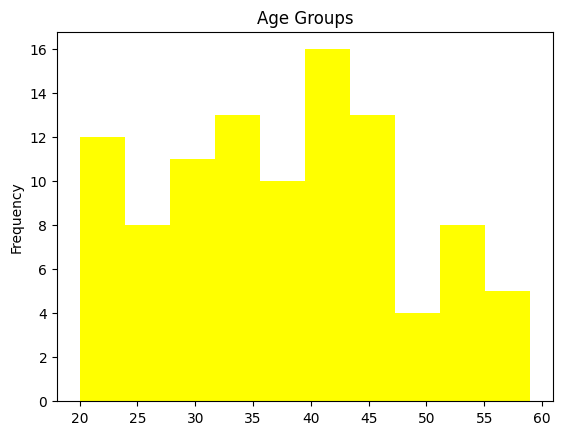

In [36]:
# 1.10 Age distribution
df['Age'].plot(kind='hist', color='yellow')
plt.title('Age Groups')
plt.show()

**Experiment 1.10 Explanation:**
Finally, we plot a histogram for 'Age'. This helps visualize the age demographics of the workforce. By observing the height of the bars, you can quickly identify the most common age group (the mode) in the company.